# Data Exploration and Preparation

## Dataset 2: COVID-QA

[Dataset2](https://www.kaggle.com/datasets/xhlulu/covidqa?select=community.csv)

### Data Description

#### **Dataset Origin and Context**

The COVID-QA community dataset is part of the COVID-QA benchmark, a curated collection of COVID-19 question–answer pairs designed for evaluating question-answering systems. The dataset aggregates over 400 Q&A pairs collected from 15 English-language news websites across four continents, reflecting a wide range of public information sources and perspectives. Each record consists of a user-oriented question, a verified answer, and a heuristically sampled negative (incorrect) answer, along with metadata describing the source and category. The dataset has been pre-cleaned using regular expressions, standardised into tabular format, and released as a CSV file, making it directly usable for retrieval-based NLP systems.

#### **Dataset Structure**

Typical columns include:
- question – Natural language COVID-19 related question
- answer – Correct, authoritative answer
- neg_answer – Incorrect or misleading answer (optional but valuable)
- source / category – Origin or thematic grouping of the Q&A pair

#### **Appropriateness for This Study**

This dataset is particularly appropriate for your research because:
- It reflects real public-facing COVID-19 queries, aligning with your focus on public health FAQs
- Answers are long-form explanatory text, ideal for chunking and retrieval

- Availability of negative answers enables:
  - Hallucination analysis
  - Faithfulness evaluation
  - Post-retrieval verification experiments

- English-only content aligns with your defined study scope

In this study, **community.csv** will serve as a primary retrieval corpus for evaluating the effectiveness of advanced, multi-stage RAG pipelines in delivering accurate and explainable COVID-19 information.

### Statistical & Exploratory Analysis

In [1]:
# Import Required Libraries

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from typing import List, Dict

In [2]:
file_path1 = "/content/drive/MyDrive/MS-LJMU/Data/covid-qa/community.csv"

In [3]:
df2 = pd.read_csv(file_path1)

In [4]:
df2.head()

,question_id,title,question,answer_id,answer,answer_type,wrong_answer,wrong_answer_type,url,source
0,14057,Can pets catch the cold?,Last night I was drying my cat with a towel af...,14083,Yes they can. The viruses that cause a cold in...,Accepted,"That is a Priapulid worm, also known as a ""pen...",Random,biology.stackexchange.com,biomedical
1,89709,Is the Common Cold an Immune Overreaction?,It's my understanding that the majority of sym...,89712,Can someone die of the common cold?\n\nNo. \nT...,Accepted,"The dash (""-"") does not represent a negative c...",Random,biology.stackexchange.com,biomedical
2,89886,Air purifier agains bacteria and viruses?,We would buy a mobile air purifier in our home...,89887,The aforementioned filter will filter microbes...,Accepted,"It's a bleu ray gelyfish, don't tauch is becau...",Random,biology.stackexchange.com,biomedical
3,89929,Why are bats the source of dangerous coronavir...,Why do coronaviruses come from bats?\n\nI mean...,89944,\n The preponderance of links between bat and...,Accepted,"First of, depending on your definition of life...",Random,biology.stackexchange.com,biomedical
4,89938,How do bats survive their own coronaviruses?,How do bats survive their own coronaviruses (w...,89975,It's common for the reservoir host of a zoonot...,Accepted,"I think that ""career in synthetic biology"" and...",Random,biology.stackexchange.com,biomedical


In [5]:
# Basic Dataset Inspection

print("Dataset Shape:", df2.shape)

print("Columns:", df2.columns.tolist())

df2.isnull().sum()

Dataset Shape: (642, 10)
Columns: ['question_id', 'title', 'question', 'answer_id', 'answer', 'answer_type', 'wrong_answer', 'wrong_answer_type', 'url', 'source']


,0
question_id,0
title,0
question,0
answer_id,0
answer,0
answer_type,0
wrong_answer,0
wrong_answer_type,0
url,0
source,0


In [6]:
# Descriptive Statistics (Text Length Analysis)

df2["question_length"] = df2["question"].str.len()
df2["answer_length"] = df2["answer"].str.len()

df2[["question_length", "answer_length"]].describe()


,question_length,answer_length
count,642.000000,642.000000
mean,895.439252,1781.647975
std,884.212927,2137.504154
min,70.000000,57.000000
25%,392.500000,721.750000
50%,677.000000,1168.500000
75%,1093.000000,2188.250000
max,11800.000000,27136.000000


In [7]:
# Token-Level Analysis (LLM-Aware)

import tiktoken

enc = tiktoken.get_encoding("cl100k_base")

df2["question_tokens"] = df2["question"].apply(lambda x: len(enc.encode(x)))
df2["answer_tokens"] = df2["answer"].apply(lambda x: len(enc.encode(x)))

df2[["question_tokens", "answer_tokens"]].describe()

,question_tokens,answer_tokens
count,642.000000,642.000000
mean,199.366044,387.366044
std,253.427306,490.110018
min,15.000000,11.000000
25%,85.000000,153.500000
50%,142.000000,249.000000
75%,234.000000,463.000000
max,3940.000000,5738.000000


In [8]:
# Duplicate & Redundancy Analysis


df2["question"].duplicated().sum()

df2["answer"].duplicated().sum()


np.int64(0)

In [9]:
# Negative Answer Analysis (Hallucination Support)

df2["neg_answer_length"] = df2["wrong_answer"].astype(str).str.len()

df2["neg_answer_length"].describe()

,neg_answer_length
count,642.000000
mean,1229.035826
std,1236.668056
min,53.000000
25%,488.500000
50%,821.000000
75%,1551.500000
max,9797.000000


### Visualisations and Insights

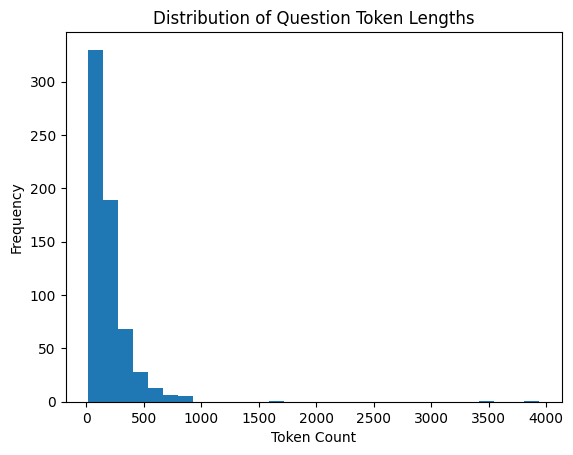

In [10]:
# Question Length Distribution

plt.figure()
plt.hist(df2["question_tokens"], bins=30)
plt.title("Distribution of Question Token Lengths")
plt.xlabel("Token Count")
plt.ylabel("Frequency")
plt.show()

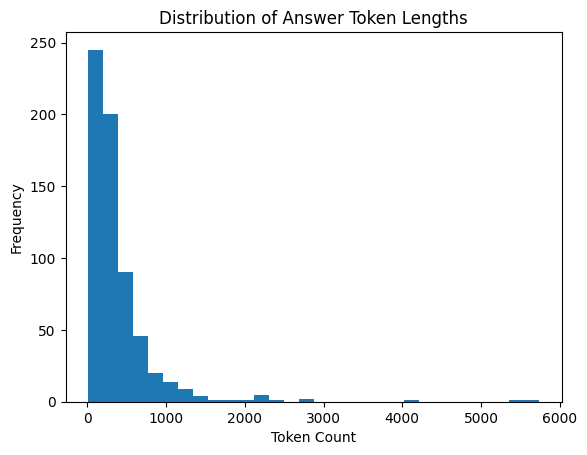

In [11]:
# Answer Length Distribution

plt.figure()
plt.hist(df2["answer_tokens"], bins=30)
plt.title("Distribution of Answer Token Lengths")
plt.xlabel("Token Count")
plt.ylabel("Frequency")
plt.show()

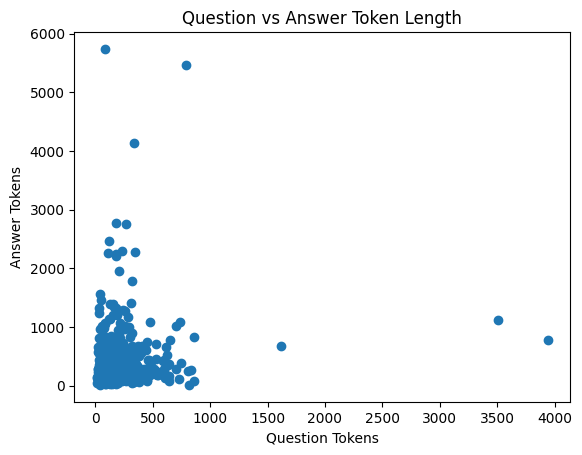

In [12]:
# Question vs Answer Length Relationship

plt.figure()
plt.scatter(df2["question_tokens"], df2["answer_tokens"])
plt.xlabel("Question Tokens")
plt.ylabel("Answer Tokens")
plt.title("Question vs Answer Token Length")
plt.show()

# Embedding Preparation

### Text Construction

In [13]:
import pandas as pd
import re

def clean_text(text: str) -> str:
    if pd.isna(text):
        return ""
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def build_document(row: pd.Series) -> str:
    parts = []

    if row.get("title"):
        parts.append(f"Title: {clean_text(row['title'])}")

    if row.get("question"):
        parts.append(f"Question: {clean_text(row['question'])}")

    if row.get("answer"):
        parts.append(f"Answer: {clean_text(row['answer'])}")

    return "\n".join(parts)

In [14]:
df2["document_text"] = df2.apply(build_document, axis=1)
df2[["document_text"]].head()

,document_text
0,Title: Can pets catch the cold?\nQuestion: Las...
1,Title: Is the Common Cold an Immune Overreacti...
2,Title: Air purifier agains bacteria and viruse...
3,Title: Why are bats the source of dangerous co...
4,Title: How do bats survive their own coronavir...


### Semantic Chunking

In [15]:
import nltk
nltk.download("punkt")
from nltk.tokenize import sent_tokenize


enc = tiktoken.get_encoding("cl100k_base")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [16]:
def chunk_text(
    text: str,
    max_tokens: int = 300,
    overlap: int = 50
):
    sentences = sent_tokenize(text)
    chunks = []
    current_chunk = []
    current_tokens = 0

    for sent in sentences:
        sent_tokens = len(enc.encode(sent))

        if current_tokens + sent_tokens > max_tokens:
            chunks.append(" ".join(current_chunk))
            current_chunk = current_chunk[-overlap:] if overlap else []
            current_tokens = len(enc.encode(" ".join(current_chunk)))

        current_chunk.append(sent)
        current_tokens += sent_tokens

    if current_chunk:
        chunks.append(" ".join(current_chunk))

    return chunks

### Metadata Creation

In [17]:
def create_chunks_with_metadata(df: pd.DataFrame):
    records = []

    for _, row in df.iterrows():
        chunks = chunk_text(row["document_text"])

        for i, chunk in enumerate(chunks):
            records.append({
                "text": chunk,
                "metadata": {
                    "question_id": row["question_id"],
                    "answer_id": row["answer_id"],
                    "chunk_id": i,
                    "source": row["source"],
                    "url": row["url"],
                    "answer_type": row["answer_type"],
                    "dataset": "COVID-QA-community"
                }
            })
    return records

In [18]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [19]:
chunked_records = create_chunks_with_metadata(df2)
len(chunked_records)

7491

In [20]:
chunked_records[23]

{'text': 'Title: Air purifier agains bacteria and viruses? Question: We would buy a mobile air purifier in our home. Against the smoke of the city, etc. It would have a HEPA + activated carbon filter. They are marketing it as: "filtration process captures 99.97% of airborne particles down to 0.1 micron in size." and having also: "encapsulated ion particle charging chamber" But the question: Would the mentioned filter+ion charger also help cleaning the air from bacteria and viruses? Ex. : "Coronavirus/2019-nCoV" is about "Coronavirus virions are spherical with diameters of approximately 125 nm" - but I just Googled it, not from an official source. And 0.1 micron is 100 nm. UPDATE: would it be more effective, if it would have UV-C light in the air purifier? Answer: The aforementioned filter will filter microbes Yes, it is routine practice to use microfiltration in labs to sterilize solutions from microbes. 0.2 micron filters will remove all typically-found bacteria most of the time, exce

# Data Indexing (Embeddings)

### FAISS: Facebook AI Similarity Search

[Link](https://docs.langchain.com/oss/python/integrations/vectorstores/faiss)

In [21]:
from openai import OpenAI
from google.colab import userdata

In [22]:
api_key = userdata.get('OPENAI_API_KEY')

In [24]:
os.environ["OPENAI_API_KEY"] = api_key

In [25]:
client = OpenAI()

In [26]:
EMBEDDING_MODEL = "text-embedding-3-large"
EMBEDDING_DIM = 3072

In [27]:
!pip install langchain_openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.8/84.8 kB 3.2 MB/s eta 0:00:00


In [28]:
!pip install -qU langchain-community faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 85.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.


In [29]:
import faiss
from langchain_community.docstore.in_memory import InMemoryDocstore
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import FAISS

In [30]:
embeddings = OpenAIEmbeddings(model=EMBEDDING_MODEL)

In [31]:
index = faiss.IndexFlatL2(EMBEDDING_DIM)

vector_store = FAISS(
    embedding_function=embeddings,
    index=index,
    docstore=InMemoryDocstore(),
    index_to_docstore_id={},
)

#### Add items to vector store

In [32]:
from uuid import uuid4
from langchain_core.documents import Document

In [33]:
documents = []

for record in chunked_records:
  text = record["text"]
  metadata = record["metadata"]
  doc = Document(
      page_content=text,
      metadata=metadata
  )
  documents.append(doc)

In [34]:
import tiktoken

encoding = tiktoken.encoding_for_model(EMBEDDING_MODEL)

def count_tokens(text: str) -> int:
    """
    Count tokens for a given text using tiktoken.
    """
    return len(encoding.encode(text))


def add_token_metadata(documents):
    """
    Adds token count to each Document's metadata.
    """
    for doc in documents:
        doc.metadata["embedding_tokens"] = count_tokens(doc.page_content)
    return documents

In [35]:
documents = add_token_metadata(documents)

In [36]:
documents[0]

Document(metadata={'question_id': 14057, 'answer_id': 14083, 'chunk_id': 0, 'source': 'biomedical', 'url': 'biology.stackexchange.com', 'answer_type': 'Accepted', 'dataset': 'COVID-QA-community', 'embedding_tokens': 299}, page_content='Title: Can pets catch the cold? Question: Last night I was drying my cat with a towel after shenanigans in the rain and she sneezed! Questions Can cats/dogs/hamsters or other pets catch the cold? How quickly do they recover? Answer: Yes they can. The viruses that cause a cold include rhinoviruses (up to 80%), coronaviruses and influenza (together accounting for much of the remaining 20%) and a small percentage of adenoviruses. When discussing cross species transfer, influenza is the most important to discuss as it is a fairly common cause of the "common cold". Influenza A has humans, pigs, bird and horses as its host. Different influenza strains have different hosts. Influenza can recombine if two strains infect the same host (antigenic shift) and also m

In [37]:
uuids = [str(uuid4()) for _ in range(len(documents))]

vector_store.add_documents(documents=documents, ids=uuids)

['5843955b-1c2b-4c6b-80e5-5ff7d932edb1',
 '8f6663b2-50df-40b2-b8f2-0933c3d1de12',
 'edb8f162-f6f2-4098-81bb-42d12bb32bfb',
 'd8cc40b6-6705-44ab-879c-524233066299',
 '6597308a-df5c-4fcb-b9e5-4619b3ad0618',
 'd6514716-8c6d-40ee-a4d5-8458c1fc343d',
 '7c3eb901-7fc5-483c-9d2b-0131ea87d77b',
 'df5b1a49-8e02-45ea-b16d-3c61798c4af8',
 '7d15a897-d797-49a9-a6bc-e7bdc2a44a97',
 'bb13f5fc-6a1d-46f8-8169-1622e300768b',
 'c8659dca-e770-434b-b6fc-688dae4a4c6c',
 'eb9d36bf-6c31-4e63-883c-695a5dc1cfd4',
 '468ec15b-3fa6-4e71-b7ae-5aaa3971d0cc',
 'd782e00b-979c-4643-941e-e2da50076db9',
 '9fd86079-0063-413f-8b91-29a43522e691',
 '6b52d503-7ae6-426d-9890-fde427c5d3fe',
 'ed4a9c39-29a1-4b8a-b479-7f9ea3609c46',
 '87e82e8b-3f0a-4959-bcf4-df72ce73c458',
 '2333885d-98e0-42e9-8447-c832c523afc4',
 'b2b7796e-2fef-4a3c-bdb2-a7984dfacde3',
 '07c149c5-4962-480c-a495-f69a9b8b0a1f',
 'c1a1af3e-dc6d-4cd0-8a6c-c0c355cef40a',
 'c08ed8d8-cefa-4d77-9791-ae99bbddb145',
 '14947836-6d56-497a-859f-08153690a206',
 '62e5dbe5-2b50-

#### Saving Vector Store

In [40]:
vector_store_path = os.path.join("/content/drive/MyDrive/MS-LJMU/Vector-Store", "Store-2-3072-COVID-QA-community")

In [41]:
vector_store.save_local(vector_store_path)

In [ ]:
results = vector_store.similarity_search(
    "What are the common symptoms of COVID-19?",
    k=5,
    filter={"dataset": "COVID-QA-community"},
)

In [ ]:
for res in results:
    print(f"* {res.page_content} [{res.metadata}]")

* Title: Can COVID-19 be damaging lung without showing fever? Question: Given that a man of 39 years without underlying health condition, is having chest discomfort and tightness, which is more discomfort during evening and night before fall asleep. He don't have cold and cough, nor have fever and he is physically active. My concern is that whether he is fighting with COVID-19 infection. Can COVID-19 be damaging the lung without showing fever? Thank you. Answer: The range of symptoms for people infected with SARS-CoV-2 are extreme. There are reports of asymptomatic children with CT scans showing viral pneumonia. Among the paediatric patients in our study, just under a third were asymptomatic. Moreover, a fifth had pneumonia only and needed radiographic examination to be identified. With respect to the question of whether one can have ongoing pneumonic process without a fever, then yes, that is possible. Case 5 in the link below presented only with a runny nose and sore throat. Fever is

In [ ]:
results

[Document(id='df4a71e2-5e53-48e2-a295-098f13feb645', metadata={'question_id': 22983, 'answer_id': 23014, 'chunk_id': 0, 'source': 'biomedical', 'url': 'health.stackexchange.com', 'answer_type': 'Reasonable', 'dataset': 'COVID-QA-community'}, page_content="Title: Can COVID-19 be damaging lung without showing fever? Question: Given that a man of 39 years without underlying health condition, is having chest discomfort and tightness, which is more discomfort during evening and night before fall asleep. He don't have cold and cough, nor have fever and he is physically active. My concern is that whether he is fighting with COVID-19 infection. Can COVID-19 be damaging the lung without showing fever? Thank you. Answer: The range of symptoms for people infected with SARS-CoV-2 are extreme. There are reports of asymptomatic children with CT scans showing viral pneumonia. Among the paediatric patients in our study, just under a third were asymptomatic. Moreover, a fifth had pneumonia only and nee